# Matching Law and the Perceptron

## Introduction

### Perceptron Model of Matching Behavior

In this project we will use a simple artificial neural network to represent the fact that organism learn to match choices with probability of rewards. We begin with a presentation of the matching law, and proceed to coding a perceptron to model a behavioral experiment in matching.

The perceptron is potentially the simplest articifical forward neural network that changes as a function of experience, and because of that an attractive model to consider the problems of how experience affects decision making.

In the exercises below you'll recreate a perceptron model that indicates how difference payoff probabilities can get encoded in the structure of a network, as it learns from experience. The implementation below is inspired in an article published in 2009, by Dawson et al. (ref [10]).

### The Matching Law

The Matching Law (ML) ([1] for a classic review, [2] for a recent one) is a model for choice behavior that robustly predicts the choices of many organisms in a variety of experiments. In its most general form, ML gives a relation between proportions of choices and frequency/quantity of rewards.

From the early demonstrations of Herrnstein, the representation of value in the brain has been a prolific field of neuroscience. Herrnstein originally showed this relation with pigeons that peck keys for food rewards in keys with varying payoffs probabilities. He found that Pigeons' key peck counts were proportional to the relative payoff of the sources. Later, Gallistel and others [4] showed that rats not only match, but do so as fast as they possibly can, adapting their choices to the changing rates of brain stimulation. More recently, Sugrue and colleagues [5] showed that neurons match: the monkey's LIP units also fire proportionally to the expectation of the reward. And these are just a few samples of the momentous advances in the field of 'neuroeconomics'.

The most basic form of matching behavior is *linear matching*, which happens when there is a linear relation between the perceived value of a choice and how often it is chosen. The formula below represents the idea.

$$ C_i = \frac{U_i}{\sum_i U_i} $$

where

$$ U_i = P(i).G(i) $$

$C_i$ stands for choice $i$, $U_i$ stands for utility of that choice. Utility is defined as the multiplication of the probability of outcome $P(i)$ by the gain obtained from decision i, $G(i)$. (A formal justification for quantifying preferences with numbers is given by Morgenstein and Von Neuman). If reward amounts are equal, then choice behavior follows the probability of pay-off, hence we say that *choice matches chance*.

## Learning Goals
- Reproduce the basic formulation of action and reward matching.
- Explain how a perceptron represents value in a decision-making task.
- Initialize perceptron weights randomly.
- Generate stochastic payoffs for a "multi-armed bandit" from specified reward probabilities.
- Update weights according to payoff outcomes.
- Visualize average weight trajectories across multiple initialized networks.

## Imports

In [ ]:
# import needful libraries

from numpy import * # flat import is convenient...
import matplotlib.pyplot as plt

# The Perceptron and the Matching Law

The perceptron is potentially the simplest articifical forward neural network that changes as a function of experience, and because of that one attractive model to consider the problems of how experience affects decision making. In the exercise below you'll recreate a perceptron model that indicates how difference payoff probabilities get encoded in the structure of a network.

The structure of the experiment recapitulates an operant conditioning experiment [10], in which the animal has a choice of four levers, each of which with a certain probability of producing a reward.

For example, the four levers could have payoff probabilities of 20, 40, 60, 80%.

The animal begins by pulling a lever at random. The lever pulled is represented by the input layer of the perceptron.

Weights are updated as a function of the observed output, as such:

$$\Delta w_i = \eta (\mathbb{R-O}) x_i $$

and the new weight becomes:

$$w_i(t+1) = \Delta w_i + w_i (t)$$

Here $w_i(t)$ is the weight, representing the probability of payoff of lever $i$. $t$ represents the epoch of training. $\eta$ is a learning rate, and $x_i$ is the lever being pulled ($x_i=1$ if lever $i$ was pulled and $0$ otherwise). When a reward was present, $\mathbb{R}=1$ and we expected it $\mathbb{O} = 1$, weights do not need to be updated. If however we did not expect it, but received, weights for that particular input are reinforced. Otherwise, they are depressed.

The output activity of the output neuron in the perceptron models the probability of expected reward, which can be observed in the change of weights over time.

### Coding Examples: Perceptron and Matching

Here we will walk you through producing the functions required for training a perceptron with the matching schedule as defined above.

 **Example 1.**
 Define a function that returns the output of a perceptron, given an input. For a transfer function we will be using the logistic sigmoid function (which is a natural way to represent choice probabilities).

 Your function should implement the following formula:

 $$y = \sigma(W^T \bf{x})$$

Here y represents the activity of a single neuron that outputs the probability of reward, while x  represents the animal's choice, a binary vector where the pressed lever is indicated with `1`. $W$ are the weights representing the neural estimator for the probability of reward for each of the levers. Finally, the sigmoid function $\sigma(x)$ is defined as

$$\sigma(x) = \frac{1}{1+e^{-x}}$$

  

In [ ]:
def perceptron(W,X):
    y = W.T @ X # same as writing y = dot(W.T, X)
    sig = 1/(1+exp(-y))
    return sig

**Example 2.** Define a function that computes the delta weight as a function of the difference between expected and observed outcomes.

In [ ]:
def delta_w(W,X,realised,eta):
    observed = perceptron(W,X);
    update = eta*(realised-observed)*X
    # update = eta*(realised)*X
    return update

**Example 3.** Define a function that produces a possible payoff outcome. Your input should be `X`. Your function should produce either a 0 or a 1, according to the probability `P` of the pulled lever.

In [ ]:
def machine_output(I, prob_payoff):
    randomizer = rng.random()
    threshold = dot(I.T,prob_payoff)
    if randomizer > threshold:
        return 0
    if randomizer < threshold:
        return 1

**Experiment Parameters:**

In [ ]:
# define the number of levers
num_levers = 4;

# Define the machine probabilities as the numpy array (a vector),
#  with the following entries [0.2, 0.4, 0.6, 0.8]:
machine_probabilities = array([[0.2], [0.4], [0.6], [0.8]])

# we set a random seed for reproducible results
rng = random.default_rng(2022)

# initialize the weigths with values from the uniform distribution from -.1 to .1
weights = rng.uniform(-.1,.1, size=(num_levers,1))

# define number of training cycles (aka, epochs)
cycles = 15000

# define learning rate
eta = 0.01

### Sample Code: Simulating a virtual pigeon

In [ ]:
# we collect the history of weights
history_w = zeros((num_levers,cycles))

flips = 1 # at the middle of the training we flip the probabilities of payoff


for j in range(cycles):

  levers = zeros((num_levers,1))
  pulled_lever = random.randint(0,num_levers)
  levers[pulled_lever,0] = 1

  a = perceptron(weights, levers)
  b = machine_output(levers, machine_probabilities)
  c = delta_w(weights, levers, b, eta)

  weights = weights + c

  history_w[:,j] = weights.T
  # history_a[:,j] =

  if j == int(cycles/(flips+1)):
      machine_probabilities = flipud(machine_probabilities)


**Plot the weights over time**

Text(0, 0.5, 'Weights')

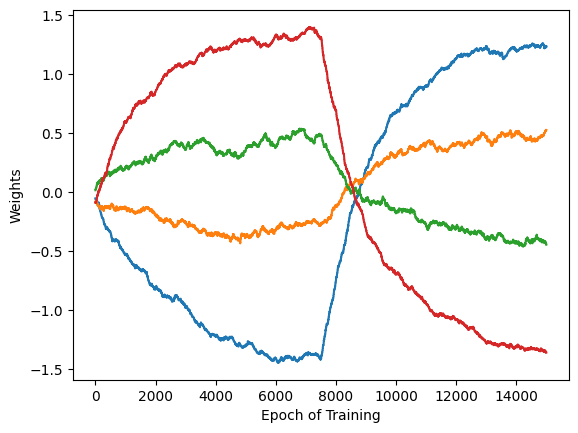

In [ ]:
plt.figure()
plt.plot(history_w.T)
plt.xlabel("Epoch of Training")
plt.ylabel("Weights")

**Exercise 1.** Above we have plotted the weights as a function of epoch. What if we wanted to know what the prediction of the perceptron for each lever would be at each epoch? Edit the code above to produce predictions of the reward value of the perceptron for each of the levers.

To do so, for each epoch you need to measure the output of the perceptron for each lever press and collect the output.

Plot the history of perceptron predictions as a function of epoch below.

In [ ]:
# your code

**Challenge.** In the "Sample Code" above, we have produced the lever presses randomly (can you find the lines where we do this?). What if our virtual pigeon would select which lever to press according to the probability represented by the perceptron's outcome?

In the code cell below copy and extend the previous simulation code and adapt the function that produces a lever press as a function of the perceptron outcomes.  for each cycle, use the activies of the perceptron to select which is the lever pressed by the pigeon.

Note: as the pigeon can only press one lever at a time, you wil have to find a system to select the 'winner' amongst the four levers.

In [ ]:
# virtual pigeon chooses according to perceptron outcomes




**Question.** What is the influence of the learning rate $\eta$ on the history of weights?

*click here to edit your answer*

## Discussion
### Matching or Maximizing?

Maximizing utility generally means to choose the source that provides more rewards more often. In the case of two probabilistic sources, say of pay-off probabilities of 20% and 40%, optimal behavior is choosing only the 40% source, where on average 4 times out of ten will be rewarded. Most animals rarely act optimally [1], rather, they match the probabilty of choosing an action with the probability of that action producing a desired outcome.

In this 20-40 case, roughly 1/3 (20/60) of the times the choice is for the leaner 20% source and 2/3 (40/60) for the richer side. In the matching case, the total pay off is (on the large numbers) of 1/3 x 20% + 2/3 x 40% = 0.33 and in the optimal case 1x40% = 0.4, clearly better.

But then, why not maximize always? Because in the real world there is more to the story than only two sources. The being that relies on resources for its subsistence faces two problems that makes maximizing a less desirable behavior. First, there is the problem of procuring sources, so at the expense of maximizing it is useful to explore and find other sources. Maximizing locally might pay off worse than investing in exploration to find new sources. The world is not known until it is explored. Second, there is the problem of updating sources, because their payoff may and will vary through time. If the being blindly maximizes, it will not learn about changes. In a changing environment, the obvious downside to this is that the source might exhaust, and the being left without alternatives. These observations give weight to the widely agreed fact that matching is often a better answer to get knowledge about rewards spread around in an unknown and shape- shifting world.
Matching also offers a cheaper mechanism in terms of memory requirements. Sebastian Seung produced a formal argument, where given some simplifying assumptions, the difference between maximizing and matching reduces to a problem of remembering. This is also intuitive: caching knowledge about sources is cheaper than keeping a history of every time a reward occurred. Therefore matching might not be such a bad idea if your brain is small.

The requirement for successful matching is a curious agent. Only through trying enough will the postulated caching memory mechanism be effective. Also from computational modeling, reinforcement learning requires quite some experience before it achieves a desirable output. Matching behavior requires the agent to peek and to poke the world, curiously probing possibilities.

# References

[1] R.J. Herrnstein. On the law of effect. Journal of the experimental analysis of behavior, 13 (2):243–266, March 1970.

[2] J.J. McDowell. On the classic and modern theories of matching. Journal of the experimental analysis of behavior, 84(1):111–137, July 2005.

[3] T.R. Vollmer and J.!Borret. An application of the matching law to evaluate the allocation of two- and three-point shots by college basketball players. Journal of Applied Behavior Analysis, 33(2):137–150, 2000.

[4] C.R. Gallistel, T.A. Mark, A.King, and P.E. Latham. The rat approximates an ideal detector of changes of rates of reward: Implications for the law of effect. Journal of Experimental Psychology: Animal Behavior Processes, 2001, (27):354–372, 2001.

[5] L.P. Sugrue, G.S. Corrado, and W.T. Newsome. Matching behavior and the representation of value in the parietal cortex. Science, 304:1782–1788, June 2004.

[6] L.P. Sugrue, G.!S. Corrado, and W.!T. Newsome. Choosing the greater of two goods: neural currencies for valuation and decision making. Nature Neuroscience Reviews, 6:363–376, May 2005.

[7] A.K. Seth. Evolving behavioral choice: An investigation into Herrnstein’s matching law. In Springer-Verlag, editor, Proceedings of the Fifth European Conference on Artificial Life, pages 225–236, 1999.


[8] A.Tversky and D.Kahneman. Judgement under uncertainty: heuristics and biases, chapter Causal Schemas in Judgements under Uncertainty, pages 117–128. Cambridge University Press, 1982.


[9] H.S. Seung. Learning in spiking neural networks by reinforcement of stochastic synaptic transmission. Neuron, 40:1063–1073, December 2003.

[10] M. Dawson, B. Dupuis, M. Spetch, and D. Kelly. Simple artificial neural networks that match probability and exploit and explore when confronting a multiarmed bandit. 20(8):1368–1371, aug 2009.


# Acknowledgements:
Mario Negrello, Creative commons license (CC4). First version of the code, Jonah Pedra (Computing Brain Student, 2021).